In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
import pandas as pd
df = pd.read_csv("HCLTECH.csv")

In [4]:
df.shape

(5300, 15)

In [5]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-11,HCLTECH,EQ,580.00,1550.0,1725.00,1492.00,1560.00,1554.45,1582.72,1192200,1.886915e+14,NaN,NaN,NaN
1,2000-01-12,HCLTECH,EQ,1554.45,1560.0,1678.85,1560.00,1678.85,1678.85,1657.05,344850,5.714349e+13,NaN,NaN,NaN
2,2000-01-13,HCLTECH,EQ,1678.85,1790.0,1813.20,1781.00,1813.20,1813.20,1804.69,53000,9.564880e+12,NaN,NaN,NaN
3,2000-01-14,HCLTECH,EQ,1813.20,1958.3,1958.30,1835.00,1958.30,1958.30,1939.90,270950,5.256169e+13,NaN,NaN,NaN
4,2000-01-17,HCLTECH,EQ,1958.30,2115.0,2115.00,1801.65,1801.65,1801.65,1990.55,428800,8.535473e+13,NaN,NaN,NaN


In [6]:
# Removing duplicates from date feature
df = df.drop_duplicates(subset='Date',keep='last')

In [7]:
df = df.sort_values("Date").reset_index(drop=True)

In [8]:
numeric_df = df.iloc[:, 3:-1]

In [9]:
numeric_df.shape

(5300, 11)

In [10]:
numeric_df.isnull().sum()

Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2844
Deliverable Volume     503
dtype: int64

In [12]:
numeric_df = numeric_df.apply(pd.to_numeric,errors='coerce')
numeric_df = numeric_df.interpolate(method="linear", limit_direction="both")
numeric_df = numeric_df.ffill().bfill()

In [13]:
numeric_df.isnull().sum()

Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
dtype: int64

In [14]:
numeric_df.head()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume
0,580.00,1550.0,1725.00,1492.00,1560.00,1554.45,1582.72,1192200,1.886915e+14,4845.0,249828.0
1,1554.45,1560.0,1678.85,1560.00,1678.85,1678.85,1657.05,344850,5.714349e+13,4845.0,249828.0
2,1678.85,1790.0,1813.20,1781.00,1813.20,1813.20,1804.69,53000,9.564880e+12,4845.0,249828.0
3,1813.20,1958.3,1958.30,1835.00,1958.30,1958.30,1939.90,270950,5.256169e+13,4845.0,249828.0
4,1958.30,2115.0,2115.00,1801.65,1801.65,1801.65,1990.55,428800,8.535473e+13,4845.0,249828.0


In [15]:
print(numeric_df.dtypes)

Prev Close            float64
Open                  float64
High                  float64
Low                   float64
Last                  float64
Close                 float64
VWAP                  float64
Volume                  int64
Turnover              float64
Trades                float64
Deliverable Volume    float64
dtype: object


In [16]:
print(numeric_df.columns)

Index(['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume',
       'Turnover', 'Trades', 'Deliverable Volume'],
      dtype='object')


In [17]:
feature_names = numeric_df.columns.tolist()
print("Features used:", feature_names)

data = numeric_df.values
num_features = data.shape[1] #No. of features in the dataset
print("No. of features: ",num_features)

print("Shape:", data.shape)

Features used: ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume']
No. of features:  11
Shape: (5300, 11)


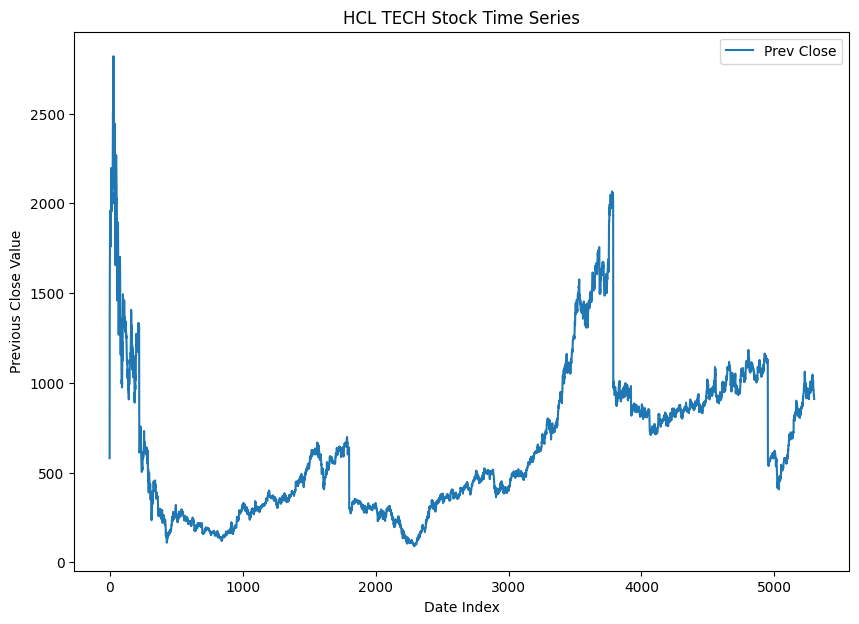

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.plot(numeric_df.index, numeric_df[feature_names[0]], label=feature_names[0])

# Titles and labels
plt.title('HCL TECH Stock Time Series')
plt.xlabel('Date Index')
plt.ylabel('Previous Close Value')

plt.legend()
plt.show()

In [19]:
data = numeric_df.values.astype(np.float32)
print("Data Shape:", data.shape)

Data Shape: (5300, 11)


In [20]:
# Train/Test split: 80/20
TRAIN_RATIO = 0.8
split_idx = int(len(data) * TRAIN_RATIO)

train_data_temp = data[:split_idx]
test_data = data[split_idx:]

# split train into train and validation sets (80:20)
val_split_idx = int(len(train_data_temp) * 0.8)

train_data = train_data_temp[:val_split_idx]
val_data = train_data_temp[val_split_idx:]

In [21]:
test_data.shape, train_data.shape, val_data.shape

((1060, 11), (3392, 11), (848, 11))

In [22]:
from sklearn.preprocessing import normalize

#axis=0 for column-wise normalization
train_data_norm = normalize(train_data, norm='l2', axis=0)
test_data_norm = normalize(test_data, norm='l2', axis=0)
val_data_norm = normalize(val_data, norm='l2', axis=0)

In [23]:
#input_steps: number of past time steps used as input=10
#output_steps: number of future time steps to predict=5
import numpy as np

INPUT_STEPS = 10
OUTPUT_STEPS = 5
BATCH_SIZE = 4

def create_sequences(data_array, input_steps=INPUT_STEPS, output_steps=OUTPUT_STEPS, overlap=1):
    X, y = [], []
    total_len = len(data_array)

    stride = input_steps - overlap
    if stride <= 0:
        raise ValueError("overlap must be smaller than input_steps")

    for i in range(0, total_len - input_steps - output_steps + 1, stride):
        X.append(data_array[i:i + input_steps])
        y.append(data_array[i + input_steps : i + input_steps + output_steps])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [24]:
X_train, y_train = create_sequences(train_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)
X_test, y_test = create_sequences(test_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)
X_val, y_val = create_sequences(val_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)

print("X_train Shape :", X_train.shape, "| y_train Shape :", y_train.shape)
print("X_test Shape :", X_test.shape, "| y_test Shape :", y_test.shape)
print("X_val Shape :", X_val.shape, "| y_val Shape :", y_val.shape)

X_train Shape : (1689, 10, 11) | y_train Shape : (1689, 5, 11)
X_test Shape : (523, 10, 11) | y_test Shape : (523, 5, 11)
X_val Shape : (417, 10, 11) | y_val Shape : (417, 5, 11)


In [25]:
from torch.utils.data import Dataset
import torch

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [26]:
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)
val_dataset = TimeSeriesDataset(X_val, y_val)

In [27]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [28]:
import torch.nn as nn

class LSTMForecaster(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(11, 10, batch_first=True)
        self.fc = nn.Linear(10, 5 * 11)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.view(-1, 5, 11)

In [29]:
import torch

model = LSTMForecaster().to(device)

lr = 0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion_MSE = nn.MSELoss()
criterion_MAE = nn.L1Loss()

def RMSELoss(y_pred, y_true):
    mse = nn.MSELoss()(y_pred, y_true)
    rmse = torch.sqrt(mse)
    return rmse

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience=10
)

In [30]:
def train_one_epoch_MSE(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion_MSE(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

In [31]:
def train_one_epoch_RMSE(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = RMSELoss(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

In [32]:
def train_one_epoch_MAE(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion_MAE(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

In [33]:
def evaluate_MSE(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion_MSE(preds, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    return avg_loss, all_preds, all_targets

In [34]:
def evaluate_RMSE(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = RMSELoss(preds, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    return avg_loss, all_preds, all_targets

In [35]:
def evaluate_MAE(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion_MAE(preds, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    return avg_loss, all_preds, all_targets

In [36]:
#Training with early stopping based on validation loss
EPOCHS = 200
PATIENCE = 20  # stop if no improvement for 20 epochs
train_losses_MSE = []
val_losses_MSE = []
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch_MSE(model, train_loader, optimizer, criterion_MSE, device)
    val_loss, _, _ = evaluate_MSE(model, val_loader, criterion_MSE, device)

    train_losses_MSE.append(train_loss)
    val_losses_MSE.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        # optional: save best model
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch [1/200] | Train Loss: 0.022205 | Val Loss: 0.012878
Epoch [2/200] | Train Loss: 0.006771 | Val Loss: 0.003189
Epoch [3/200] | Train Loss: 0.001403 | Val Loss: 0.000909
Epoch [4/200] | Train Loss: 0.000280 | Val Loss: 0.000609
Epoch [5/200] | Train Loss: 0.000135 | Val Loss: 0.000590
Epoch [6/200] | Train Loss: 0.000126 | Val Loss: 0.000573
Epoch [7/200] | Train Loss: 0.000124 | Val Loss: 0.000557
Epoch [8/200] | Train Loss: 0.000123 | Val Loss: 0.000573
Epoch [9/200] | Train Loss: 0.000122 | Val Loss: 0.000539
Epoch [10/200] | Train Loss: 0.000122 | Val Loss: 0.000540
Epoch [11/200] | Train Loss: 0.000121 | Val Loss: 0.000535
Epoch [12/200] | Train Loss: 0.000120 | Val Loss: 0.000572
Epoch [13/200] | Train Loss: 0.000119 | Val Loss: 0.000547
Epoch [14/200] | Train Loss: 0.000119 | Val Loss: 0.000548
Epoch [15/200] | Train Loss: 0.000118 | Val Loss: 0.000536
Epoch [16/200] | Train Loss: 0.000117 | Val Loss: 0.000495
Epoch [17/200] | Train Loss: 0.000116 | Val Loss: 0.000530
Epoch 

In [37]:
#Training with early stopping based on validation loss
EPOCHS = 200
PATIENCE = 20  # stop if no improvement for 20 epochs
train_losses_RMSE = []
val_losses_RMSE = []
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch_RMSE(model, train_loader, optimizer, RMSELoss, device)
    val_loss, _, _ = evaluate_RMSE(model, val_loader, RMSELoss, device)

    train_losses_RMSE.append(train_loss)
    val_losses_RMSE.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        # optional: save best model
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch [1/200] | Train Loss: 0.005394 | Val Loss: 0.010895
Epoch [2/200] | Train Loss: 0.005306 | Val Loss: 0.010993
Epoch [3/200] | Train Loss: 0.005345 | Val Loss: 0.010835
Epoch [4/200] | Train Loss: 0.005358 | Val Loss: 0.011211
Epoch [5/200] | Train Loss: 0.005326 | Val Loss: 0.010703
Epoch [6/200] | Train Loss: 0.005286 | Val Loss: 0.010993
Epoch [7/200] | Train Loss: 0.005312 | Val Loss: 0.010944
Epoch [8/200] | Train Loss: 0.005303 | Val Loss: 0.011077
Epoch [9/200] | Train Loss: 0.005341 | Val Loss: 0.010797
Epoch [10/200] | Train Loss: 0.005300 | Val Loss: 0.011092
Epoch [11/200] | Train Loss: 0.005301 | Val Loss: 0.010788
Epoch [12/200] | Train Loss: 0.005290 | Val Loss: 0.010925
Epoch [13/200] | Train Loss: 0.005278 | Val Loss: 0.010954
Epoch [14/200] | Train Loss: 0.005317 | Val Loss: 0.010943
Epoch [15/200] | Train Loss: 0.005314 | Val Loss: 0.010744
Epoch [16/200] | Train Loss: 0.005315 | Val Loss: 0.010896
Epoch [17/200] | Train Loss: 0.005280 | Val Loss: 0.010886
Epoch 

In [38]:
#Training with early stopping based on validation loss
EPOCHS = 200
PATIENCE = 20  # stop if no improvement for 20 epochs
train_losses_MAE = []
val_losses_MAE = []
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch_MAE(model, train_loader, optimizer, criterion_MAE, device)
    val_loss, _, _ = evaluate_MAE(model, val_loader, criterion_MAE, device)

    train_losses_MAE.append(train_loss)
    val_losses_MAE.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        # optional: save best model
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch [1/200] | Train Loss: 0.002172 | Val Loss: 0.005386
Epoch [2/200] | Train Loss: 0.002158 | Val Loss: 0.005339
Epoch [3/200] | Train Loss: 0.002142 | Val Loss: 0.005278
Epoch [4/200] | Train Loss: 0.002140 | Val Loss: 0.005254
Epoch [5/200] | Train Loss: 0.002137 | Val Loss: 0.005297
Epoch [6/200] | Train Loss: 0.002129 | Val Loss: 0.005307
Epoch [7/200] | Train Loss: 0.002125 | Val Loss: 0.005406
Epoch [8/200] | Train Loss: 0.002128 | Val Loss: 0.005297
Epoch [9/200] | Train Loss: 0.002124 | Val Loss: 0.005353
Epoch [10/200] | Train Loss: 0.002126 | Val Loss: 0.005499
Epoch [11/200] | Train Loss: 0.002120 | Val Loss: 0.005333
Epoch [12/200] | Train Loss: 0.002113 | Val Loss: 0.005332
Epoch [13/200] | Train Loss: 0.002115 | Val Loss: 0.005274
Epoch [14/200] | Train Loss: 0.002107 | Val Loss: 0.005257
Epoch [15/200] | Train Loss: 0.002111 | Val Loss: 0.005333
Epoch [16/200] | Train Loss: 0.002115 | Val Loss: 0.005330
Epoch [17/200] | Train Loss: 0.002115 | Val Loss: 0.005317
Epoch 

In [39]:
# evaluation of model on Test dataset using MSE Loss
test_loss_MSE, predictions_MSE, targets = evaluate_MSE(model, test_loader, criterion_MSE, device)
print("\nFinal Test Loss:", test_loss_MSE)


Final Test Loss: 0.00011952010256911732


In [40]:
# evaluation of model on Test dataset using RMSE Loss
test_loss_RMSE, predictions_RMSE, targets = evaluate_RMSE(model, test_loader, RMSELoss, device)
print("\nFinal Test Loss:", test_loss_RMSE)


Final Test Loss: 0.008755152911503387


In [41]:
# evaluation of model on Test dataset using MSE Loss
test_loss_MAE, predictions_MAE, targets = evaluate_MAE(model, test_loader, criterion_MAE, device)
print("\nFinal Test Loss:", test_loss_MAE)


Final Test Loss: 0.004443375171156846


In [42]:
print("Predictions Values using MSE Loss:\n",predictions_MSE)

Predictions Values using MSE Loss:
 [[[0.02694969 0.02900143 0.02821807 ... 0.01379956 0.01894042 0.01042522]
  [0.02813597 0.02730699 0.02814898 ... 0.01328658 0.0181062  0.01038931]
  [0.02843464 0.02823741 0.02672286 ... 0.01371955 0.01815269 0.00938463]
  [0.02807187 0.02758525 0.02827147 ... 0.01357321 0.01755196 0.00962847]
  [0.02803004 0.02811489 0.02802218 ... 0.01292862 0.01954645 0.01031432]]

 [[0.02707471 0.02858037 0.02824385 ... 0.0146797  0.02320495 0.01211984]
  [0.02789758 0.02749647 0.02846587 ... 0.01501261 0.02167853 0.01176717]
  [0.02816814 0.02827374 0.02670455 ... 0.01491009 0.02260514 0.01082357]
  [0.02797797 0.02767363 0.02821442 ... 0.01535062 0.02123122 0.01163071]
  [0.02811817 0.02824998 0.02762704 ... 0.01462909 0.02363685 0.01146707]]

 [[0.02710728 0.0287878  0.02802847 ... 0.01152019 0.01830129 0.00989451]
  [0.02810566 0.02754297 0.02843472 ... 0.01153453 0.01718729 0.009878  ]
  [0.02858548 0.02804048 0.02713186 ... 0.01178126 0.01748015 0.00943335

In [43]:
print("Predictions Values using RMSE Loss:\n",predictions_RMSE)

Predictions Values using RMSE Loss:
 [[[0.02694969 0.02900143 0.02821807 ... 0.01379956 0.01894042 0.01042522]
  [0.02813597 0.02730699 0.02814898 ... 0.01328658 0.0181062  0.01038931]
  [0.02843464 0.02823741 0.02672286 ... 0.01371955 0.01815269 0.00938463]
  [0.02807187 0.02758525 0.02827147 ... 0.01357321 0.01755196 0.00962847]
  [0.02803004 0.02811489 0.02802218 ... 0.01292862 0.01954645 0.01031432]]

 [[0.02707471 0.02858037 0.02824385 ... 0.0146797  0.02320495 0.01211984]
  [0.02789758 0.02749647 0.02846587 ... 0.01501261 0.02167853 0.01176717]
  [0.02816814 0.02827374 0.02670455 ... 0.01491009 0.02260514 0.01082357]
  [0.02797797 0.02767363 0.02821442 ... 0.01535062 0.02123122 0.01163071]
  [0.02811817 0.02824998 0.02762704 ... 0.01462909 0.02363685 0.01146707]]

 [[0.02710728 0.0287878  0.02802847 ... 0.01152019 0.01830129 0.00989451]
  [0.02810566 0.02754297 0.02843472 ... 0.01153453 0.01718729 0.009878  ]
  [0.02858548 0.02804048 0.02713186 ... 0.01178126 0.01748015 0.0094333

In [44]:
print("Predictions Values using MAE Loss:\n",predictions_MAE)

Predictions Values using MAE Loss:
 [[[0.02694969 0.02900143 0.02821807 ... 0.01379956 0.01894042 0.01042522]
  [0.02813597 0.02730699 0.02814898 ... 0.01328658 0.0181062  0.01038931]
  [0.02843464 0.02823741 0.02672286 ... 0.01371955 0.01815269 0.00938463]
  [0.02807187 0.02758525 0.02827147 ... 0.01357321 0.01755196 0.00962847]
  [0.02803004 0.02811489 0.02802218 ... 0.01292862 0.01954645 0.01031432]]

 [[0.02707471 0.02858037 0.02824385 ... 0.0146797  0.02320495 0.01211984]
  [0.02789758 0.02749647 0.02846587 ... 0.01501261 0.02167853 0.01176717]
  [0.02816814 0.02827374 0.02670455 ... 0.01491009 0.02260514 0.01082357]
  [0.02797797 0.02767363 0.02821442 ... 0.01535062 0.02123122 0.01163071]
  [0.02811817 0.02824998 0.02762704 ... 0.01462909 0.02363685 0.01146707]]

 [[0.02710728 0.0287878  0.02802847 ... 0.01152019 0.01830129 0.00989451]
  [0.02810566 0.02754297 0.02843472 ... 0.01153453 0.01718729 0.009878  ]
  [0.02858548 0.02804048 0.02713186 ... 0.01178126 0.01748015 0.00943335

In [45]:
print("Targets Values:\n",targets)

Targets Values:
 [[[0.02756948 0.02733373 0.02749801 ... 0.02718689 0.04012377 0.04334182]
  [0.02766464 0.02763933 0.02798791 ... 0.0117673  0.0223354  0.01676284]
  [0.02811329 0.02801283 0.0280416  ... 0.0070799  0.01063281 0.00950378]
  [0.02823564 0.02835238 0.02806844 ... 0.00683359 0.0142442  0.01078935]
  [0.02800962 0.02797888 0.02777316 ... 0.00810662 0.01725774 0.01335923]]

 [[0.02811329 0.02801283 0.0280416  ... 0.0070799  0.01063281 0.00950378]
  [0.02823564 0.02835238 0.02806844 ... 0.00683359 0.0142442  0.01078935]
  [0.02800962 0.02797888 0.02777316 ... 0.00810662 0.01725774 0.01335923]
  [0.02772412 0.0278091  0.02748291 ... 0.00869377 0.00962057 0.01693018]
  [0.02747941 0.02753576 0.02759197 ... 0.00969229 0.01774376 0.0154679 ]]

 [[0.02800962 0.02797888 0.02777316 ... 0.00810662 0.01725774 0.01335923]
  [0.02772412 0.0278091  0.02748291 ... 0.00869377 0.00962057 0.01693018]
  [0.02747941 0.02753576 0.02759197 ... 0.00969229 0.01774376 0.0154679 ]
  [0.02786008 0.0

In [46]:
feature_names

['Prev Close',
 'Open',
 'High',
 'Low',
 'Last',
 'Close',
 'VWAP',
 'Volume',
 'Turnover',
 'Trades',
 'Deliverable Volume']

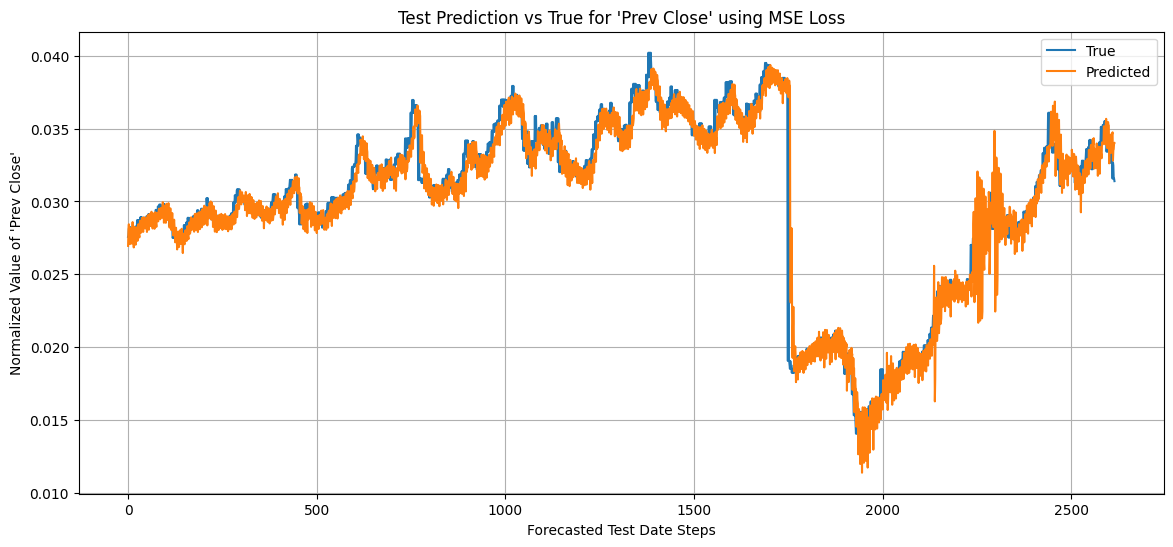

In [47]:
# Plot predictions vs targets values using MSE Loss
PLOT_FEATURE = "Prev Close" 

if PLOT_FEATURE not in feature_names:
    raise ValueError(f"{PLOT_FEATURE} not found. Choose from: {feature_names}")

feature_idx = feature_names.index(PLOT_FEATURE)

pred_feature = predictions_MSE[:, :, feature_idx].reshape(-1)
true_feature = targets[:, :, feature_idx].reshape(-1)

plt.figure(figsize=(14, 6))
plt.plot(true_feature, label="True")
plt.plot(pred_feature, label="Predicted")

plt.title(f"Test Prediction vs True for '{PLOT_FEATURE}' using MSE Loss")
plt.xlabel("Forecasted Test Date Steps")
plt.ylabel(f"Normalized Value of '{PLOT_FEATURE}'")

plt.legend()
plt.grid(True)
plt.show()

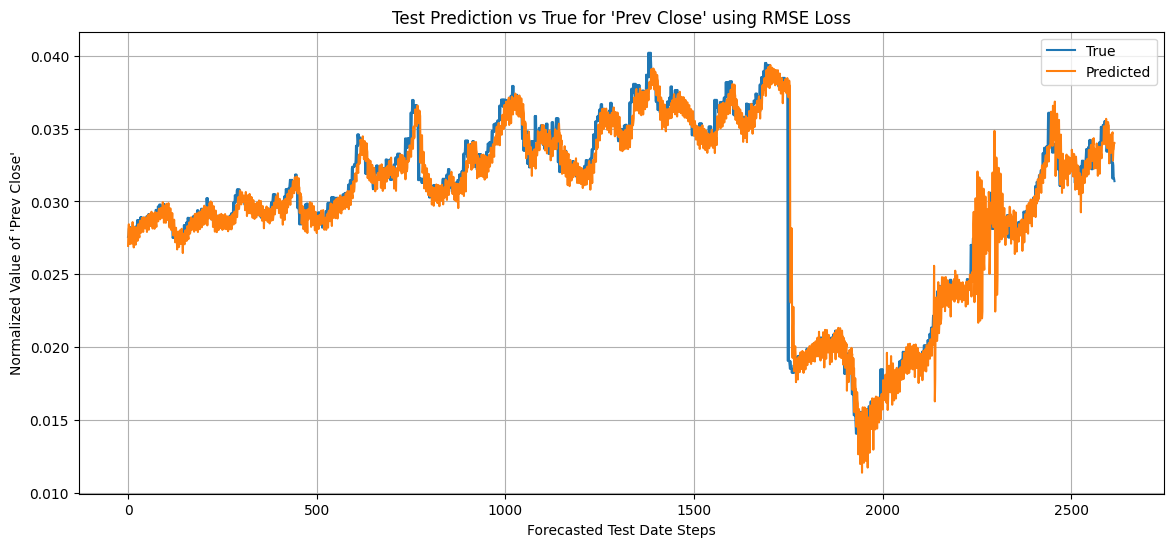

In [48]:
# Plot predictions vs targets values using RMSE Loss
PLOT_FEATURE = "Prev Close" 

if PLOT_FEATURE not in feature_names:
    raise ValueError(f"{PLOT_FEATURE} not found. Choose from: {feature_names}")

feature_idx = feature_names.index(PLOT_FEATURE)

pred_feature = predictions_RMSE[:, :, feature_idx].reshape(-1)
true_feature = targets[:, :, feature_idx].reshape(-1)

plt.figure(figsize=(14, 6))
plt.plot(true_feature, label="True")
plt.plot(pred_feature, label="Predicted")

plt.title(f"Test Prediction vs True for '{PLOT_FEATURE}' using RMSE Loss")
plt.xlabel("Forecasted Test Date Steps")
plt.ylabel(f"Normalized Value of '{PLOT_FEATURE}'")

plt.legend()
plt.grid(True)
plt.show()

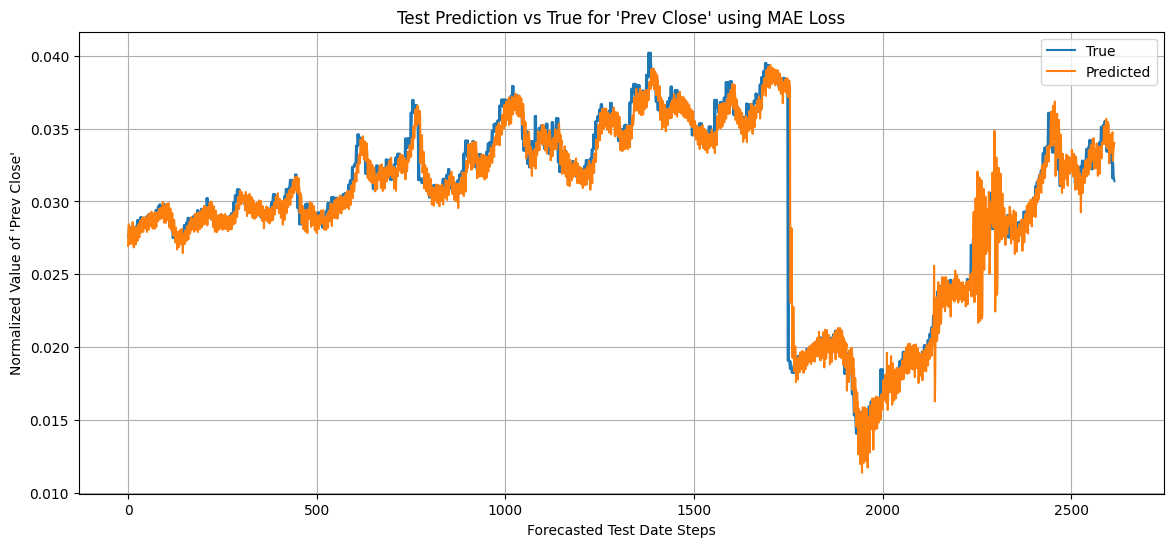

In [49]:
# Plot predictions vs targets values using MAE Loss
PLOT_FEATURE = "Prev Close" 

if PLOT_FEATURE not in feature_names:
    raise ValueError(f"{PLOT_FEATURE} not found. Choose from: {feature_names}")

feature_idx = feature_names.index(PLOT_FEATURE)

pred_feature = predictions_MAE[:, :, feature_idx].reshape(-1)
true_feature = targets[:, :, feature_idx].reshape(-1)

plt.figure(figsize=(14, 6))
plt.plot(true_feature, label="True")
plt.plot(pred_feature, label="Predicted")

plt.title(f"Test Prediction vs True for '{PLOT_FEATURE}' using MAE Loss")
plt.xlabel("Forecasted Test Date Steps")
plt.ylabel(f"Normalized Value of '{PLOT_FEATURE}'")

plt.legend()
plt.grid(True)
plt.show()

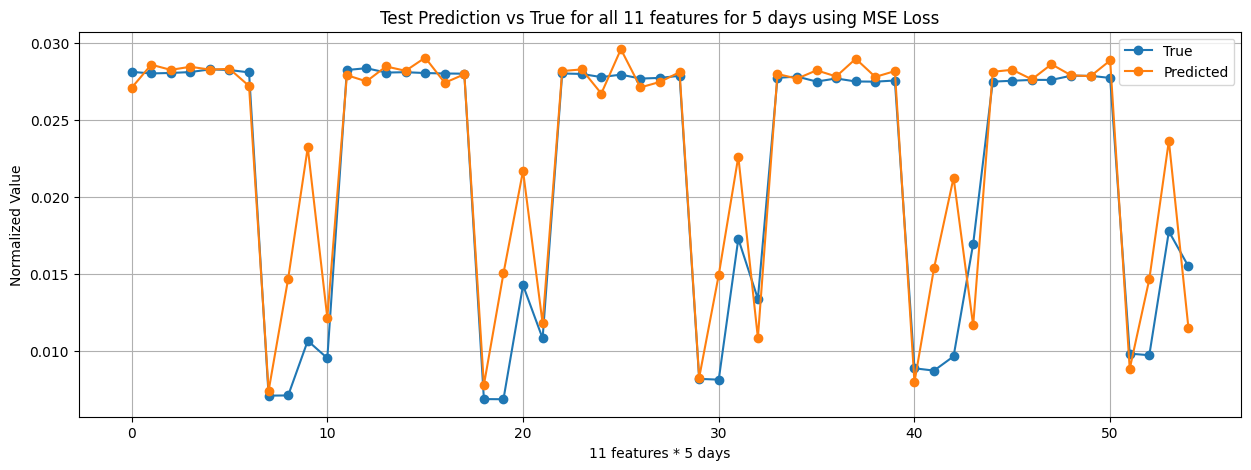

In [50]:
# Plot predictions vs targets values using MSE Loss for 5 days

pred_feature = predictions_MSE[1, :, :].reshape(-1)
true_feature = targets[1, :, :].reshape(-1)

plt.figure(figsize=(15, 5))
plt.plot(true_feature, marker='o', label="True")
plt.plot(pred_feature, marker='o', label="Predicted")

plt.title(f"Test Prediction vs True for all 11 features for 5 days using MSE Loss")
plt.xlabel("11 features * 5 days")
plt.ylabel(f"Normalized Value")

plt.legend()
plt.grid(True)
plt.show()

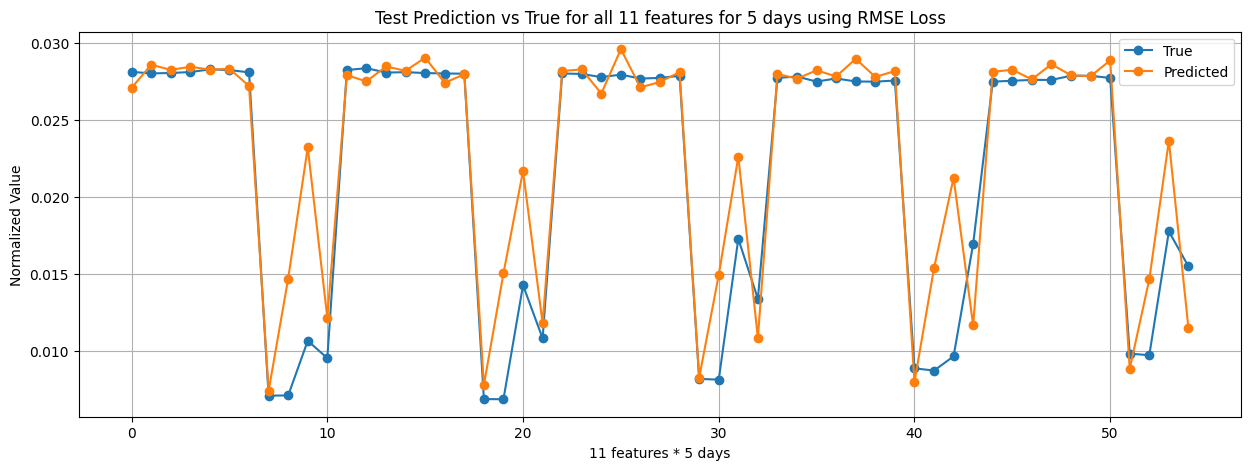

In [51]:
# Plot predictions vs targets values using MSE Loss for 5 days

pred_feature = predictions_RMSE[1, :, :].reshape(-1)
true_feature = targets[1, :, :].reshape(-1)

plt.figure(figsize=(15, 5))
plt.plot(true_feature, marker='o', label="True")
plt.plot(pred_feature, marker='o', label="Predicted")

plt.title(f"Test Prediction vs True for all 11 features for 5 days using RMSE Loss")
plt.xlabel("11 features * 5 days")
plt.ylabel(f"Normalized Value")

plt.legend()
plt.grid(True)
plt.show()

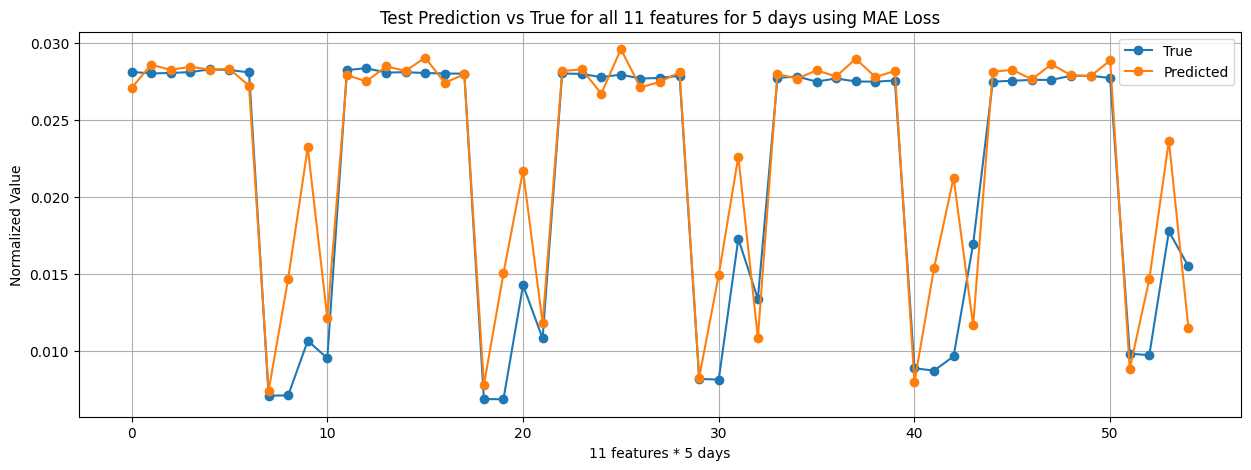

In [53]:
# Plot predictions vs targets values using MAE Loss for 5 days

pred_feature = predictions_MAE[1, :, :].reshape(-1)
true_feature = targets[1, :, :].reshape(-1)

plt.figure(figsize=(15, 5))
plt.plot(true_feature, marker='o', label="True")
plt.plot(pred_feature, marker='o', label="Predicted")

plt.title(f"Test Prediction vs True for all 11 features for 5 days using MAE Loss")
plt.xlabel("11 features * 5 days")
plt.ylabel(f"Normalized Value")

plt.legend()
plt.grid(True)
plt.show()